# Phase 2.3 - Data Validation

## Objective

This notebook validates the quality of the PJM Hourly Energy Consumption dataset before preprocessing and model training.

Validation includes:

- Schema Validation
- Datatype Validation
- Missing Value Validation
- Duplicate Validation
- Missing Timestamp Validation
- Frequency Validation
- Value Range Validation
- Outlier Validation
- Chronological Order Validation
- Validation Summary Report

In [28]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [29]:
DATA_PATH = Path("../data/raw/PJME_hourly.csv")

df = pd.read_csv(DATA_PATH)

df["Datetime"] = pd.to_datetime(df["Datetime"])

df.set_index("Datetime", inplace=True)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [30]:
expected_columns = ["PJME_MW"]

print("="*60)
print("SCHEMA VALIDATION")
print("="*60)

if list(df.columns) == expected_columns:
    print("✅ Schema Validation Passed")
else:
    print("❌ Schema Validation Failed")
    print("Expected :", expected_columns)
    print("Found    :", list(df.columns))

SCHEMA VALIDATION
✅ Schema Validation Passed


In [31]:
print("="*60)
print("DATATYPE VALIDATION")
print("="*60)

print(df.dtypes)

if np.issubdtype(df.index.dtype, np.datetime64):
    print("\n✅ Datetime Index Valid")
else:
    print("\n❌ Datetime Index Invalid")

DATATYPE VALIDATION
PJME_MW    float64
dtype: object

✅ Datetime Index Valid


In [32]:
print("="*60)
print("MISSING VALUE VALIDATION")
print("="*60)

missing = df.isnull().sum()

print(missing)

if missing.sum()==0:
    print("\n✅ No Missing Values")
else:
    print("\n❌ Missing Values Found")

MISSING VALUE VALIDATION
PJME_MW    0
dtype: int64

✅ No Missing Values


In [33]:
duplicate_records = (
    df.reset_index()
      .duplicated(subset=["Datetime", "PJME_MW"])
      .sum()
)

print("Duplicate records:", duplicate_records)

Duplicate records: 0


In [34]:
print("=" * 60)
print("DUPLICATE TIMESTAMP VALIDATION")
print("=" * 60)

duplicate_index = df.index.duplicated().sum()

print(f"Duplicate Timestamps Before: {duplicate_index}")

if duplicate_index > 0:
    # Keep the first occurrence of each duplicate timestamp
    df = df[~df.index.duplicated(keep="first")]

    print(f"✅ Removed {duplicate_index} duplicate timestamp(s).")
else:
    print("✅ No duplicate timestamps found.")

print(f"Duplicate Timestamps After: {df.index.duplicated().sum()}")

DUPLICATE TIMESTAMP VALIDATION
Duplicate Timestamps Before: 4
✅ Removed 4 duplicate timestamp(s).
Duplicate Timestamps After: 0


In [35]:
print("=" * 60)
print("MISSING TIMESTAMP VALIDATION & INTERPOLATION")
print("=" * 60)

# Create complete hourly index
expected_range = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="h"
)

# Find missing timestamps
missing_timestamp = expected_range.difference(df.index)

print(f"Missing timestamps before: {len(missing_timestamp)}")

if len(missing_timestamp) > 0:
    # Add missing timestamps
    df = df.reindex(expected_range)

    # Rename index
    df.index.name = "Datetime"

    # Count missing values before interpolation
    print(f"Missing values before interpolation: {df['PJME_MW'].isna().sum()}")

    # Time-based interpolation
    df["PJME_MW"] = df["PJME_MW"].interpolate(method="time")

    print("✅ Missing timestamps added and interpolated successfully.")

else:
    print("✅ No missing timestamps found.")

print(f"Missing values after interpolation: {df['PJME_MW'].isna().sum()}")
print(f"Dataset shape after interpolation: {df.shape}")

MISSING TIMESTAMP VALIDATION & INTERPOLATION


Missing timestamps before: 30
Missing values before interpolation: 30
✅ Missing timestamps added and interpolated successfully.
Missing values after interpolation: 0
Dataset shape after interpolation: (145392, 1)


In [36]:
print("="*60)
print("FREQUENCY VALIDATION")
print("="*60)

frequency = pd.infer_freq(df.index)

print("Detected Frequency :",frequency)

if frequency=="h":
    print("✅ Hourly Dataset")
else:
    print("⚠ Frequency Could Not Be Inferred")

FREQUENCY VALIDATION
Detected Frequency : h
✅ Hourly Dataset


In [37]:
df = df.sort_index()
print(df.index.is_monotonic_increasing)
print("="*60)
print("CHRONOLOGICAL ORDER VALIDATION")
print("="*60)

if df.index.is_monotonic_increasing:
    print("✅ Data Sorted Chronologically")
else:
    print("❌ Data Not Sorted")

True
CHRONOLOGICAL ORDER VALIDATION
✅ Data Sorted Chronologically


In [38]:
negative=(df["PJME_MW"]<0).sum()

print("="*60)
print("VALUE RANGE VALIDATION")
print("="*60)

print("Negative Values :",negative)

if negative==0:
    print("✅ Passed")
else:
    print("❌ Failed")

VALUE RANGE VALIDATION
Negative Values : 0
✅ Passed


In [39]:
Q1=df["PJME_MW"].quantile(.25)
Q3=df["PJME_MW"].quantile(.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

outliers=df[(df["PJME_MW"]<lower)|(df["PJME_MW"]>upper)]

print("="*60)
print("IQR OUTLIER VALIDATION")
print("="*60)

print("Outliers :",len(outliers))

IQR OUTLIER VALIDATION
Outliers : 3460


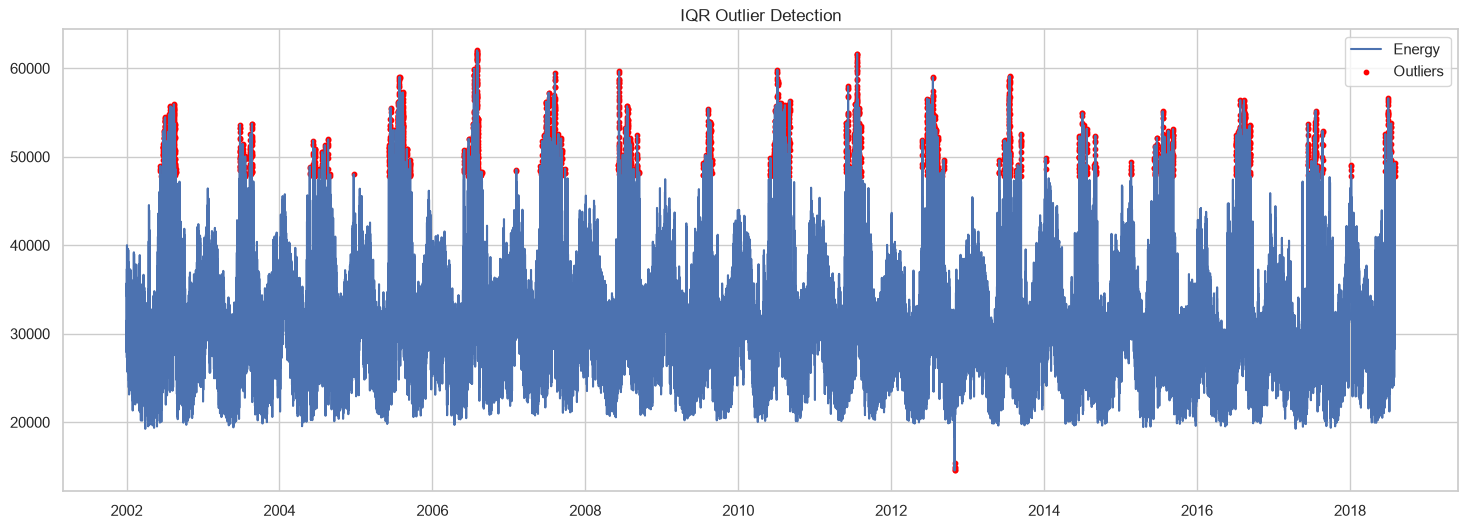

In [40]:
plt.figure(figsize=(18,6))

plt.plot(df.index,df["PJME_MW"],label="Energy")

plt.scatter(
    outliers.index,
    outliers["PJME_MW"],
    color="red",
    s=10,
    label="Outliers"
)

plt.legend()

plt.title("IQR Outlier Detection")

plt.show()

In [48]:
summary = pd.DataFrame({
    "Validation": [
        "Schema",
        "Datatype",
        "Missing Values",
        "Duplicate Records",
        "Duplicate Timestamps",
        "Missing Timestamps",
        "Chronological Order",
        "Frequency",
        "Negative Values"
    ],

    "Status": [
        "✅ Pass" if list(df.columns) == ["PJME_MW"] else "❌ Fail",

        "✅ Pass" if np.issubdtype(df.index.dtype, np.datetime64) else "❌ Fail",

        "✅ Pass" if df.isnull().sum().sum() == 0 else "❌ Fail",

        "✅ Pass" if (
            df.reset_index()
              .duplicated(subset=["Datetime", "PJME_MW"])
              .sum() == 0
        ) else "❌ Fail",

        "✅ Pass" if df.index.duplicated().sum() == 0 else "❌ Fail",

        "✅ Pass" if len(
            pd.date_range(
                start=df.index.min(),
                end=df.index.max(),
                freq="h"
            ).difference(df.index)
        ) == 0 else "❌ Fail",

        "✅ Pass" if df.index.is_monotonic_increasing else "❌ Fail",

        "✅ Pass" if pd.infer_freq(df.index) is not None else "❌ Fail",

        "✅ Pass" if (df["PJME_MW"] < 0).sum() == 0 else "❌ Fail"
    ]
})

summary

,Validation,Status
0,Schema,✅ Pass
1,Datatype,✅ Pass
2,Missing Values,✅ Pass
3,Duplicate Records,✅ Pass
4,Duplicate Timestamps,✅ Pass
5,Missing Timestamps,✅ Pass
6,Chronological Order,✅ Pass
7,Frequency,✅ Pass
8,Negative Values,✅ Pass
